### **biz-brains-academy-sinhala**

In [1]:
import pandas as pd
from pathlib import Path

base = Path("bizbrainsData/data")

files = {
    "train":      "train-00000-of-00001.parquet",
    "validation": "validation-00000-of-00001.parquet",
    "test":       "test-00000-of-00001.parquet",
}

dfBizBrains = pd.concat(
    [pd.read_parquet(base / f).assign(split=name) for name, f in files.items()],
    ignore_index=True,
)

print(dfBizBrains.shape)
print(dfBizBrains["split"].value_counts())

(979, 4)
split
train         685
test          196
validation     98
Name: count, dtype: int64


In [2]:
dfBizBrains.head(5)

,audio,text,speaker_gender,split
0,{'bytes': b'RIFF\xe4X\x05\x00WAVEfmt \x10\x00\...,"එතකොට ඔය EPF එක, ETF එක හදුන්වල දීපු කාලේ තිබි...",male,train
1,{'bytes': b'RIFF\xf4!\x04\x00WAVEfmt \x10\x00\...,මේ වගේ crisis වලින් පාඩම් ඉගෙන ගෙන මේවට contro...,male,train
2,{'bytes': b'RIFF$\xf7\x03\x00WAVEfmt \x10\x00\...,ඒකට medical බිල් එකක්. ඕවා monthly installment...,male,train
3,{'bytes': b'RIFF\xe4\xae\x04\x00WAVEfmt \x10\x...,අනිත් කාරණේ personal loan අරන් දැන් සමහර කට්ටි...,male,train
4,{'bytes': b'RIFF$\xc8\x05\x00WAVEfmt \x10\x00\...,Loan එක දීලා ඒක recover කරනවා. මොකද මිනිස්සුන්...,male,train


In [3]:
print("Total utterances:", len(dfBizBrains))
print("Unique speakers (if ID encodes speaker):", dfBizBrains["speaker_gender"].str[:4].nunique())
print("missing transcripts:", dfBizBrains["text"].isnull().sum())


Total utterances: 979
Unique speakers (if ID encodes speaker): 2
missing transcripts: 0


In [4]:
dfBizBrains["text_len"] = dfBizBrains["text"].str.len()
dfBizBrains["text_len"].describe()

count    979.000000
mean     152.320735
std       64.189196
min       33.000000
25%      110.000000
50%      134.000000
75%      176.500000
max      416.000000
Name: text_len, dtype: float64

In [5]:
import io
import soundfile as sf

def get_duration(audio):
    if audio is None:
        return None
    # HF Audio feature -> dict; otherwise raw bytes
    raw = audio['bytes'] if isinstance(audio, dict) else audio
    if raw is None:
        return None
    try:
        info = sf.info(io.BytesIO(raw))
        return info.duration
    except Exception:
        return None

dfBizBrains['duration'] = dfBizBrains['audio'].apply(get_duration)


In [6]:
dfBizBrains['duration'].describe()

count    979.000000
mean       9.479393
std        3.753861
min        5.010000
25%        7.075000
50%        8.360000
75%       10.700000
max       24.840000
Name: duration, dtype: float64

In [7]:
from IPython.display import Audio, display

row = dfBizBrains.loc[dfBizBrains['duration'].idxmax()]
raw = row['audio']['bytes'] if isinstance(row['audio'], dict) else row['audio']

display(Audio(data=raw))
print(row['duration'], "sec")
print(row['text'])

24.84 sec
එතකොට දැන් forth fifth year එක වෙනවා එතකොට ඔයා බලන්න ඕන  තව කොහොමද මේක diversify වෙන්න පුළුවන් කියලා එතකොට චූටි risk එකක් ගන්න පුළුවන් රවී ඔයාට ඒ කියන්නේ මොකක්ද දැන් emergency fund එකකුත් තියෙනවා right කතන්දරේ තියෙනවා හැබැයි මේ වෙද්දි රවී  ඔයා අත ගහන්න බෑ වාහනෙට ඒ කියන්නේ වාහනේ upgration එහෙකට හරි නැත්තං හිතන්නකෝ දැනට pick me එකක ගියපු ඔයා එක ගියපු ඔයා දැනට මොකක් හරි uber එකේ ගියපු එයා


In [8]:
idx = dfBizBrains['duration'].idxmax()
dfBizBrains.at[idx, 'text'] = "එතකොට දැන් forth fifth year එක වෙනවා එතකොට ඔයා බලන්න ඕන  තව කොහොමද මේක diversify වෙන්න පුළුවන් කියලා එතකොට චූටි risk එකක් ගන්න පුළුවන් රවී ඔයාට ඒ කියන්නේ මොකක්ද දැන් emergency fund එකකුත් තියෙනවා right කතන්දරේ තියෙනවා හැබැයි මේ වෙද්දි රවී  ඔයා අත ගහන්න බෑ වාහනෙට ඒ කියන්නේ වාහනේ upgration එහෙකට හරි නැත්තං හිතන්නකෝ දැනට pick me එකක ගියපු ඔයා එක ගියපු ඔයා දැනට මොකක් හරි uber එකේ ගියපු ඔයා"

## **Transcript-audio alignment issues**

In [9]:
import numpy as np
from IPython.display import Audio, display

# chars/sec — flags misaligned or mispaired audio/text
df = dfBizBrains
df['chars_per_sec'] = df['text'].str.len() / df['duration']
print(df['chars_per_sec'].describe())

suspicious = df[(df['chars_per_sec'] > 30) | (df['chars_per_sec'] < 2)]
print(f"Suspicious rows: {len(suspicious)} of {len(df)}")

def play(idx):
    row = df.loc[idx]
    raw = row['audio']['bytes'] if isinstance(row['audio'], dict) else row['audio']
    print(f"[{idx}] {row['duration']:.2f}s | {row['chars_per_sec']:.1f} chars/sec")
    print(row['text'])
    display(Audio(data=raw))

# worst offender
if len(suspicious):
    play(suspicious['chars_per_sec'].idxmax())

count    979.000000
mean      16.130883
std        2.781463
min        2.275862
25%       14.308819
50%       16.082384
75%       18.106586
max       26.465927
Name: chars_per_sec, dtype: float64
Suspicious rows: 0 of 979


## **Empty or garbage transcripts**

In [10]:
text = df['text'].fillna('').str.strip()

empty_text = df[text == '']
very_short_text = df[(text != '') & (text.str.len() < 3)]

print(f"Empty/whitespace: {len(empty_text)}")
print(f"Very short (<3 chars): {len(very_short_text)}")

Empty/whitespace: 0
Very short (<3 chars): 0


## **Duplicates**

In [11]:
import hashlib

text = df['text'].fillna('').str.strip()

# --- duplicate transcripts ---
dup_mask = text.duplicated(keep=False) & (text != '')
print(f"Rows with a duplicated transcript: {dup_mask.sum()}")

dup_groups = df[dup_mask].groupby(text[dup_mask]).groups   # transcript -> index labels
print(f"Distinct duplicated transcripts: {len(dup_groups)}")

for t, idxs in list(dup_groups.items())[:3]:
    print(f"\n--- {t[:120]}")
    print(df.loc[idxs, ['duration', 'chars_per_sec']].to_string())

Rows with a duplicated transcript: 0
Distinct duplicated transcripts: 0


## **Non-target-language contamination**

In [12]:
import re

SINHALA = re.compile(r'[\u0D80-\u0DFF]')
text = df['text'].fillna('')

df['sinhala_ratio'] = text.apply(
    lambda t: len(SINHALA.findall(t)) / max(len(re.sub(r'\s', '', t)), 1)
)

no_sinhala = df[df['sinhala_ratio'] == 0]
mostly_latin = df[(df['sinhala_ratio'] > 0) & (df['sinhala_ratio'] < 0.3)]

print(f"No Sinhala at all: {len(no_sinhala)}")
print(f"Mostly non-Sinhala (<30%): {len(mostly_latin)}")
print(df.loc[no_sinhala.index, ['duration', 'text']].head(10).to_string())

No Sinhala at all: 0
Mostly non-Sinhala (<30%): 4
Empty DataFrame
Columns: [duration, text]
Index: []


In [19]:
from tqdm.auto import tqdm

def get_bytes(cell):
    if isinstance(cell, dict):
        return cell["bytes"]
    if isinstance(cell, (bytes, bytearray, np.ndarray)):
        return bytes(cell)
    raise TypeError(type(cell))

rows = []
for i, cell in tqdm(df['audio'].items(), total=len(df), desc="headers"):
    r = {"idx": i, "error": None}
    try:
        b = get_bytes(cell)
        r["n_bytes"] = len(b)
        info = sf.info(io.BytesIO(b))
        r.update(sr=info.samplerate, channels=info.channels, subtype=info.subtype,
                 fmt=info.format, frames=info.frames,
                 duration=info.frames / info.samplerate)
    except Exception as e:
        r["error"] = f"{type(e).__name__}: {e}"
    rows.append(r)

meta = pd.DataFrame(rows).set_index("idx")
meta = df[["split", 'text', "speaker_gender"]].join(meta)
print("unreadable:", meta.error.notna().sum())
display(meta[meta.error.notna()].head())
meta.head()

headers: 100%|██████████| 979/979 [00:00<00:00, 33174.37it/s]

unreadable: 0


,split,text,speaker_gender,error,n_bytes,sr,channels,subtype,fmt,frames,duration


,split,text,speaker_gender,error,n_bytes,sr,channels,subtype,fmt,frames,duration
0,train,"එතකොට ඔය EPF එක, ETF එක හදුන්වල දීපු කාලේ තිබි...",male,None,350444,16000,1,PCM_16,WAV,175200,10.9500
1,train,මේ වගේ crisis වලින් පාඩම් ඉගෙන ගෙන මේවට contro...,male,None,270844,16000,1,PCM_16,WAV,135400,8.4625
2,train,ඒකට medical බිල් එකක්. ඕවා monthly installment...,male,None,259884,16000,1,PCM_16,WAV,129920,8.1200
3,train,අනිත් කාරණේ personal loan අරන් දැන් සමහර කට්ටි...,male,None,306924,16000,1,PCM_16,WAV,153440,9.5900
4,train,Loan එක දීලා ඒක recover කරනවා. මොකද මිනිස්සුන්...,male,None,378924,16000,1,PCM_16,WAV,189440,11.8400


In [20]:

ok = meta[meta.error.isna()].copy()

overall = pd.Series({
    "n_clips": len(ok),
    "hours":   ok.duration.sum()/3600,
    "min_s":   ok.duration.min(),
    "p50_s":   ok.duration.quantile(.50),
    "p95_s":   ok.duration.quantile(.95),
    "p99_s":   ok.duration.quantile(.99),
    "max_s":   ok.duration.max(),
    "mean_s":  ok.duration.mean(),
}).round(2)
display(overall.to_frame("bizbrains"))

per_split = ok.groupby("split").duration.agg(
    n_clips="size",
    hours=lambda s: s.sum()/3600,
    min_s="min",
    p50_s=lambda s: s.quantile(.50),
    p95_s=lambda s: s.quantile(.95),
    p99_s=lambda s: s.quantile(.99),
    max_s="max",
).round(2)
for lbl, m in [("over_30s", ok.duration > 30), ("over_29s", ok.duration > 29),
               ("under_0.5s", ok.duration < 0.5)]:
    per_split[lbl] = ok[m].groupby("split").size().reindex(per_split.index, fill_value=0)
display(per_split)

print(f"clips exceeding Whisper's 30 s window: {(ok.duration > 30).sum()}")

,bizbrains
n_clips,979.00
hours,2.58
min_s,5.01
p50_s,8.36
p95_s,18.14
p99_s,22.12
max_s,24.84
mean_s,9.48


,n_clips,hours,min_s,p50_s,p95_s,p99_s,max_s,over_30s,over_29s,under_0.5s
split,,,,,,,,,,
test,196,0.53,5.01,8.44,19.18,22.89,24.84,0,0,0
train,685,1.80,5.03,8.30,17.81,21.00,24.07,0,0,0
validation,98,0.25,5.14,8.25,15.84,19.03,20.53,0,0,0


clips exceeding Whisper's 30 s window: 0


In [21]:
display(ok.groupby(["sr", "channels", "subtype", "fmt"]).size()
          .rename("count").reset_index().sort_values("count", ascending=False))

print("not 16 kHz:", (ok.sr != 16000).sum(), "->", sorted(ok.sr.unique().tolist()))
print("not mono  :", (ok.channels != 1).sum())
print("subtypes  :", ok.subtype.value_counts().to_dict())

low = ok[ok.sr < 16000]
if len(low):
    print(f"\n⚠ {len(low)} clips below 16 kHz ({low.duration.sum()/3600:.2f} h) "
          "— band-limited; upsampling cannot recover this")
    display(low.groupby(["split", "sr"]).size())

,sr,channels,subtype,fmt,count
0,16000,1,PCM_16,WAV,979


not 16 kHz: 0 -> [16000]
not mono  : 0
subtypes  : {'PCM_16': 979}


In [24]:
SIL_DBFS, FRAME, HOP = -45.0, 1024, 512  #FRAME = no of samples per frame, HOP = no of samples to hop between frames(overlap)

def frame_rms(x):
    if len(x) < FRAME:
        return np.array([np.sqrt(np.mean(x**2) + 1e-12)])
    n = 1 + (len(x) - FRAME)//HOP #no of frames
    idx = np.arange(FRAME)[None, :] + HOP*np.arange(n)[:, None]
    return np.sqrt(np.mean(x[idx]**2, axis=1) + 1e-12)

def analyse(b):
    x, sr = sf.read(io.BytesIO(b), dtype="float32", always_2d=True)
    x = x.mean(axis=1)
    d = len(x)/sr
    voiced = 20*np.log10(frame_rms(x)) > SIL_DBFS
    hop_s = HOP/sr
    if voiced.any():
        lead  = np.argmax(voiced) * hop_s
        trail = max(0.0, d - (len(voiced)-1-np.argmax(voiced[::-1])) * hop_s)
    else:
        lead = trail = d
    to_db = lambda v: 20*np.log10(max(float(v), 1e-10))
    return dict(peak_dbfs=to_db(np.abs(x).max()),
                rms_dbfs=to_db(np.sqrt(np.mean(x**2))),
                clip_frac=float((np.abs(x) >= .999).mean()),
                silence_frac=float((~voiced).mean()),
                lead_sil_s=float(lead), trail_sil_s=float(trail))

recs = []
for i in tqdm(ok.index, desc="levels + silence"):
    try:
        recs.append({"idx": i, **analyse(get_bytes(df.at[i, 'audio']))})
    except Exception as e:
        recs.append({"idx": i, "err": str(e)})

lv = pd.DataFrame(recs).set_index("idx").join(ok[["split", 'text', "duration"]])
lv.head()

levels + silence: 100%|██████████| 979/979 [00:01<00:00, 699.81it/s]


,peak_dbfs,rms_dbfs,clip_frac,silence_frac,lead_sil_s,trail_sil_s,split,text,duration
idx,,,,,,,,,
0,-2.830907,-20.679448,0.0,0.073314,0.0,0.0700,train,"එතකොට ඔය EPF එක, ETF එක හදුන්වල දීපු කාලේ තිබි...",10.9500
1,-8.501016,-23.501778,0.0,0.133080,0.0,0.0785,train,මේ වගේ crisis වලින් පාඩම් ඉගෙන ගෙන මේවට contro...,8.4625
2,-3.501703,-22.242303,0.0,0.170635,0.0,0.0880,train,ඒකට medical බිල් එකක්. ඕවා monthly installment...,8.1200
3,-4.015647,-22.458861,0.0,0.171141,0.0,0.0860,train,අනිත් කාරණේ personal loan අරන් දැන් සමහර කට්ටි...,9.5900
4,-4.722505,-23.274338,0.0,0.119241,0.0,0.0640,train,Loan එක දීලා ඒක recover කරනවා. මොකද මිනිස්සුන්...,11.8400


,rms_dbfs,peak_dbfs,clip_frac,silence_frac,lead_sil_s,trail_sil_s
count,979.00,979.00,979.0,979.00,979.00,979.00
mean,-23.10,-4.34,0.0,0.14,0.01,0.08
std,1.72,1.82,0.0,0.06,0.05,0.03
min,-32.88,-15.51,0.0,0.00,0.00,0.06
5%,-27.11,-7.37,0.0,0.05,0.00,0.06
25%,-23.51,-5.32,0.0,0.10,0.00,0.07
50%,-22.85,-4.10,0.0,0.14,0.00,0.08
75%,-22.18,-3.02,0.0,0.18,0.00,0.09
95%,-20.95,-1.90,0.0,0.24,0.00,0.09
max,-19.49,-0.18,0.0,0.35,0.83,0.62


,rms_dbfs,peak_dbfs,clip_frac,silence_frac,lead_sil_s,trail_sil_s
split,,,,,,
test,-22.79,-4.13,0.0,0.14,0.0,0.08
train,-22.89,-4.10,0.0,0.14,0.0,0.08
validation,-22.76,-3.86,0.0,0.14,0.0,0.08


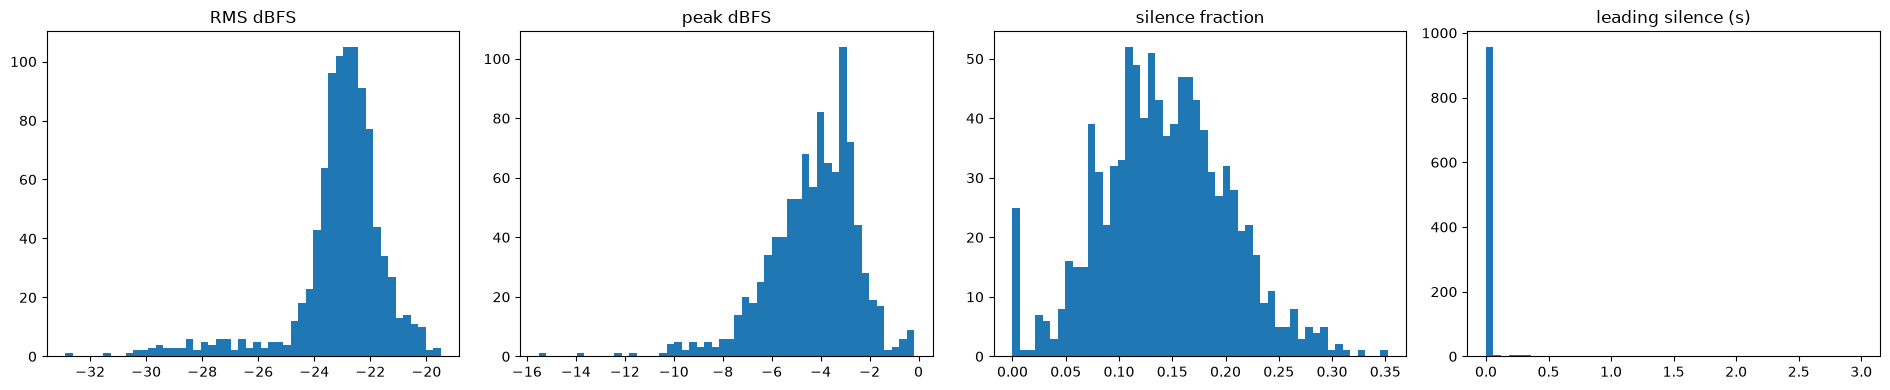

,n_clips
near_silent,0
very_quiet,0
clipped,0
mostly_silence,0
long_lead_sil,0
long_trail_sil,0


,near_silent,very_quiet,clipped,mostly_silence,long_lead_sil,long_trail_sil
split,,,,,,
test,0,0,0,0,0,0
train,0,0,0,0,0,0
validation,0,0,0,0,0,0


,split,duration,rms_dbfs,clip_frac,silence_frac,lead_sil_s,n_flags
idx,,,,,,,
0,train,10.950000,-20.679448,0.0,0.073314,0.0,0
1,train,8.462500,-23.501778,0.0,0.133080,0.0,0
2,train,8.120000,-22.242303,0.0,0.170635,0.0,0
3,train,9.590000,-22.458861,0.0,0.171141,0.0,0
4,train,11.840000,-23.274338,0.0,0.119241,0.0,0
5,train,7.360000,-26.295966,0.0,0.100437,0.0,0
6,train,9.220000,-22.660035,0.0,0.132404,0.0,0
7,train,20.340000,-21.986484,0.0,0.181388,0.0,0
8,train,10.400000,-28.532613,0.0,0.209877,0.0,0


In [29]:
import matplotlib.pyplot as plt

cols = ["rms_dbfs", "peak_dbfs", "clip_frac", "silence_frac", "lead_sil_s", "trail_sil_s"]
display(lv[cols].describe(percentiles=[.05, .25, .5, .75, .95]).round(2))
display(lv.groupby("split")[cols].median().round(2))

fig, ax = plt.subplots(1, 4, figsize=(19, 4))
ax[0].hist(lv.rms_dbfs.dropna(), bins=50);              ax[0].set_title("RMS dBFS")
ax[1].hist(lv.peak_dbfs.dropna(), bins=50);             ax[1].set_title("peak dBFS")
ax[2].hist(lv.silence_frac.dropna(), bins=50);          ax[2].set_title("silence fraction")
ax[3].hist(lv.lead_sil_s.dropna(), bins=50, range=(0,3)); ax[3].set_title("leading silence (s)")
plt.tight_layout(); plt.show()

flags = pd.DataFrame({
    "near_silent":    lv.rms_dbfs < -50,
    "very_quiet":     lv.rms_dbfs.between(-50, -38),
    "clipped":        lv.clip_frac > .001,
    "mostly_silence": lv.silence_frac > .60,
    "long_lead_sil":  lv.lead_sil_s > 1.5,
    "long_trail_sil": lv.trail_sil_s > 1.5,
})
flags["split"] = lv.split
display(flags.drop(columns="split").sum().to_frame("n_clips"))
display(flags.groupby("split").sum())

lv["n_flags"] = flags.drop(columns="split").sum(axis=1)
display(lv.sort_values("n_flags", ascending=False)
          .head(15)[["split", "duration", "rms_dbfs", "clip_frac",
                     "silence_frac", "lead_sil_s", "n_flags"]])

In [28]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 133.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 107.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 138.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 161.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


In [31]:
from IPython.display import Audio as PlayAudio, display as disp

def play(i):
    x, sr = sf.read(io.BytesIO(get_bytes(df.at[i, 'audio'])), dtype="float32", always_2d=True)
    print(f"[{i}] {df.at[i,'split']} | {sr} Hz | {len(x)/sr:.2f}s | {df.at[i,'speaker_gender']}")
    print(df.at[i, 'text'][:300])
    disp(PlayAudio(x.mean(axis=1), rate=sr))

for i in lv.sort_values("n_flags", ascending=False).index[:6]:
    play(i)
    print("-" * 80)

[0] train | 16000 Hz | 10.95s | male
එතකොට ඔය EPF එක, ETF එක හදුන්වල දීපු කාලේ තිබිච්ච ආර්ථික තත්වයයි ඒ දේවල් නෙවෙ ලංකාවෙ දැන් තියෙන්නෙ. දැන් අපි generation ගානක් පහු කරල. එතකොට EPF, ETF එක විතරක් මදි.


--------------------------------------------------------------------------------
[1] train | 16000 Hz | 8.46s | male
මේ වගේ crisis වලින් පාඩම් ඉගෙන ගෙන මේවට controls දාලා ඒ continuous environment එක business එක ඇතුලේ තියෙන්න ඕන. Learning


--------------------------------------------------------------------------------
[2] train | 16000 Hz | 8.12s | male
ඒකට medical බිල් එකක්. ඕවා monthly installment plan එකකට. ඒ වගේ දේවල් වලට යන්න මේ credit card එක පාවිච්චි කරලා. personal loan එකක්


--------------------------------------------------------------------------------
[3] train | 16000 Hz | 9.59s | male
අනිත් කාරණේ personal loan අරන් දැන් සමහර කට්ටියට මෙක හරි ගිහිල්ලා ඇති මගෙන් මේ ලඟදි එක් කෙනෙක් ඇවිල්ලා ඇහුව මේ personal loan එකක් අරන් මේ share market දැම්මොත්


--------------------------------------------------------------------------------
[4] train | 16000 Hz | 11.84s | male
Loan එක දීලා ඒක recover කරනවා. මොකද මිනිස්සුන්ගේ සල්ලි වලටත් වග කියන්න එපැයි. ඉතිං එතකොට ඔයා දැනගන්න ඕන තමන්ගේ capital structure එකට කොච්චර ප්‍රමාණයකින් ණය ගන්න පුළුවන්ද කියලා. ඒක දරන්න බැරි තාක් කල් loan එකකට යන්න එපා.


--------------------------------------------------------------------------------
[5] train | 16000 Hz | 7.36s | male
මේ ඒ වැඩ ටික plan කරගන්න ඒ විදිහට සහ අර EBE සහ මේ දවස් වල තියෙන අපේ  මේ මේ market එකේ තියෙන


--------------------------------------------------------------------------------
